In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from scipy.sparse import issparse

import gc

sc.settings.set_figure_params(
    dpi=300,           
    frameon=False,     
    #figsize=(6, 5),    
    fontsize=16,       
    #format='pdf'     
)

## COMPARE UMAP FOR:

1. No regression (all genes except histone/cell cycle)
2. Cell cycle regression (wrong for VASAseq; all genes except histone/cell cycle)
3. Histone regression (all genes except histone/cell cycle)
4. Histone regression filtering non-coding RNA 

with the 'best parameters' found.

In [2]:
# --- LOAD DATA ---
adata1 = sc.read_h5ad("../data/data_filtered_raw.h5ad")
adata2 = sc.read_h5ad("../data/data_standard_norm_regress_lncRNA_WRONG.h5ad")
adata3 = sc.read_h5ad("../data/data_standard_norm_regress_lncRNA.h5ad")
adata4 = sc.read_h5ad("../data/data_standard_norm_regress_lncRNA_protein_coding.h5ad")

## ELBOW PLOT

We look for the critical point in the elbow plot in order to infer the correct number of PC to use

Analytical detection of the tipping point: furthest point of the data of an imaginary line traced between the minimum and maximum value in the variance for different PC number.

In [3]:
def find_optimal_pcs_analytical(adata, n_pcs_total=50):
    """
    Finds the Knee point of the PCA variance ratio curve geometrically.
    """

    # --- PCA for 50 components to map the tail ---
    sc.tl.pca(adata, svd_solver='arpack', n_comps=50) 

    # Get variance ratio (eigenvalues normalized)
    variance_ratio = adata.uns['pca']['variance_ratio']
    
    # x and y coordinates (normalized to 0-1 range for geometry)
    x = np.arange(len(variance_ratio))
    y = variance_ratio
    
    # Normalize to unit square to treat x and y equally
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    # Coordinates of the line connecting start (P1) and end (P2)
    # Line equation: Ax + By + C = 0
    # Vector P1->P2 = (x2-x1, y2-y1)
    # Normal vector = (y1-y2, x2-x1)
    
    P1 = np.array([x_norm[0], y_norm[0]])
    P2 = np.array([x_norm[-1], y_norm[-1]])
    
    # Distance from each point to the line defined by P1 and P2
    # d = |(x2-x1)(y1-y0) - (x1-x0)(y2-y1)| / sqrt((x2-x1)^2 + (y2-y1)^2)
    # Here P0 is the point on the curve (x_norm[i], y_norm[i])
    
    numerator = np.abs((P2[0]-P1[0])*(P1[1]-y_norm) - (P1[0]-x_norm)*(P2[1]-P1[1]))
    denominator = np.sqrt((P2[0]-P1[0])**2 + (P2[1]-P1[1])**2)
    
    distances = numerator / denominator
    
    # The knee is the point with max distance
    knee_index = np.argmax(distances)
    
    return knee_index + 1 # +1 because indices start at 0

# --- EXECUTE ---
optimal_pc_analytical1 = find_optimal_pcs_analytical(adata1)
optimal_pc_analytical2 = find_optimal_pcs_analytical(adata2)
optimal_pc_analytical3 = find_optimal_pcs_analytical(adata3)
optimal_pc_analytical4 = find_optimal_pcs_analytical(adata4)

print(f"Knee no regression: {optimal_pc_analytical1} PCs")
print(f"Knee cell cycle regression: {optimal_pc_analytical2} PCs")
print(f"Knee histone regression: {optimal_pc_analytical3} PCs")
print(f"Knee histone regression + non-coding protein filtering: {optimal_pc_analytical4} PCs")

Knee no regression: 3 PCs
Knee cell cycle regression: 8 PCs
Knee histone regression: 9 PCs
Knee histone regression + non-coding protein filtering: 7 PCs


## PCA / UMAP configuration

IMPORTANT PARAMETER => min_dist = 0.1 

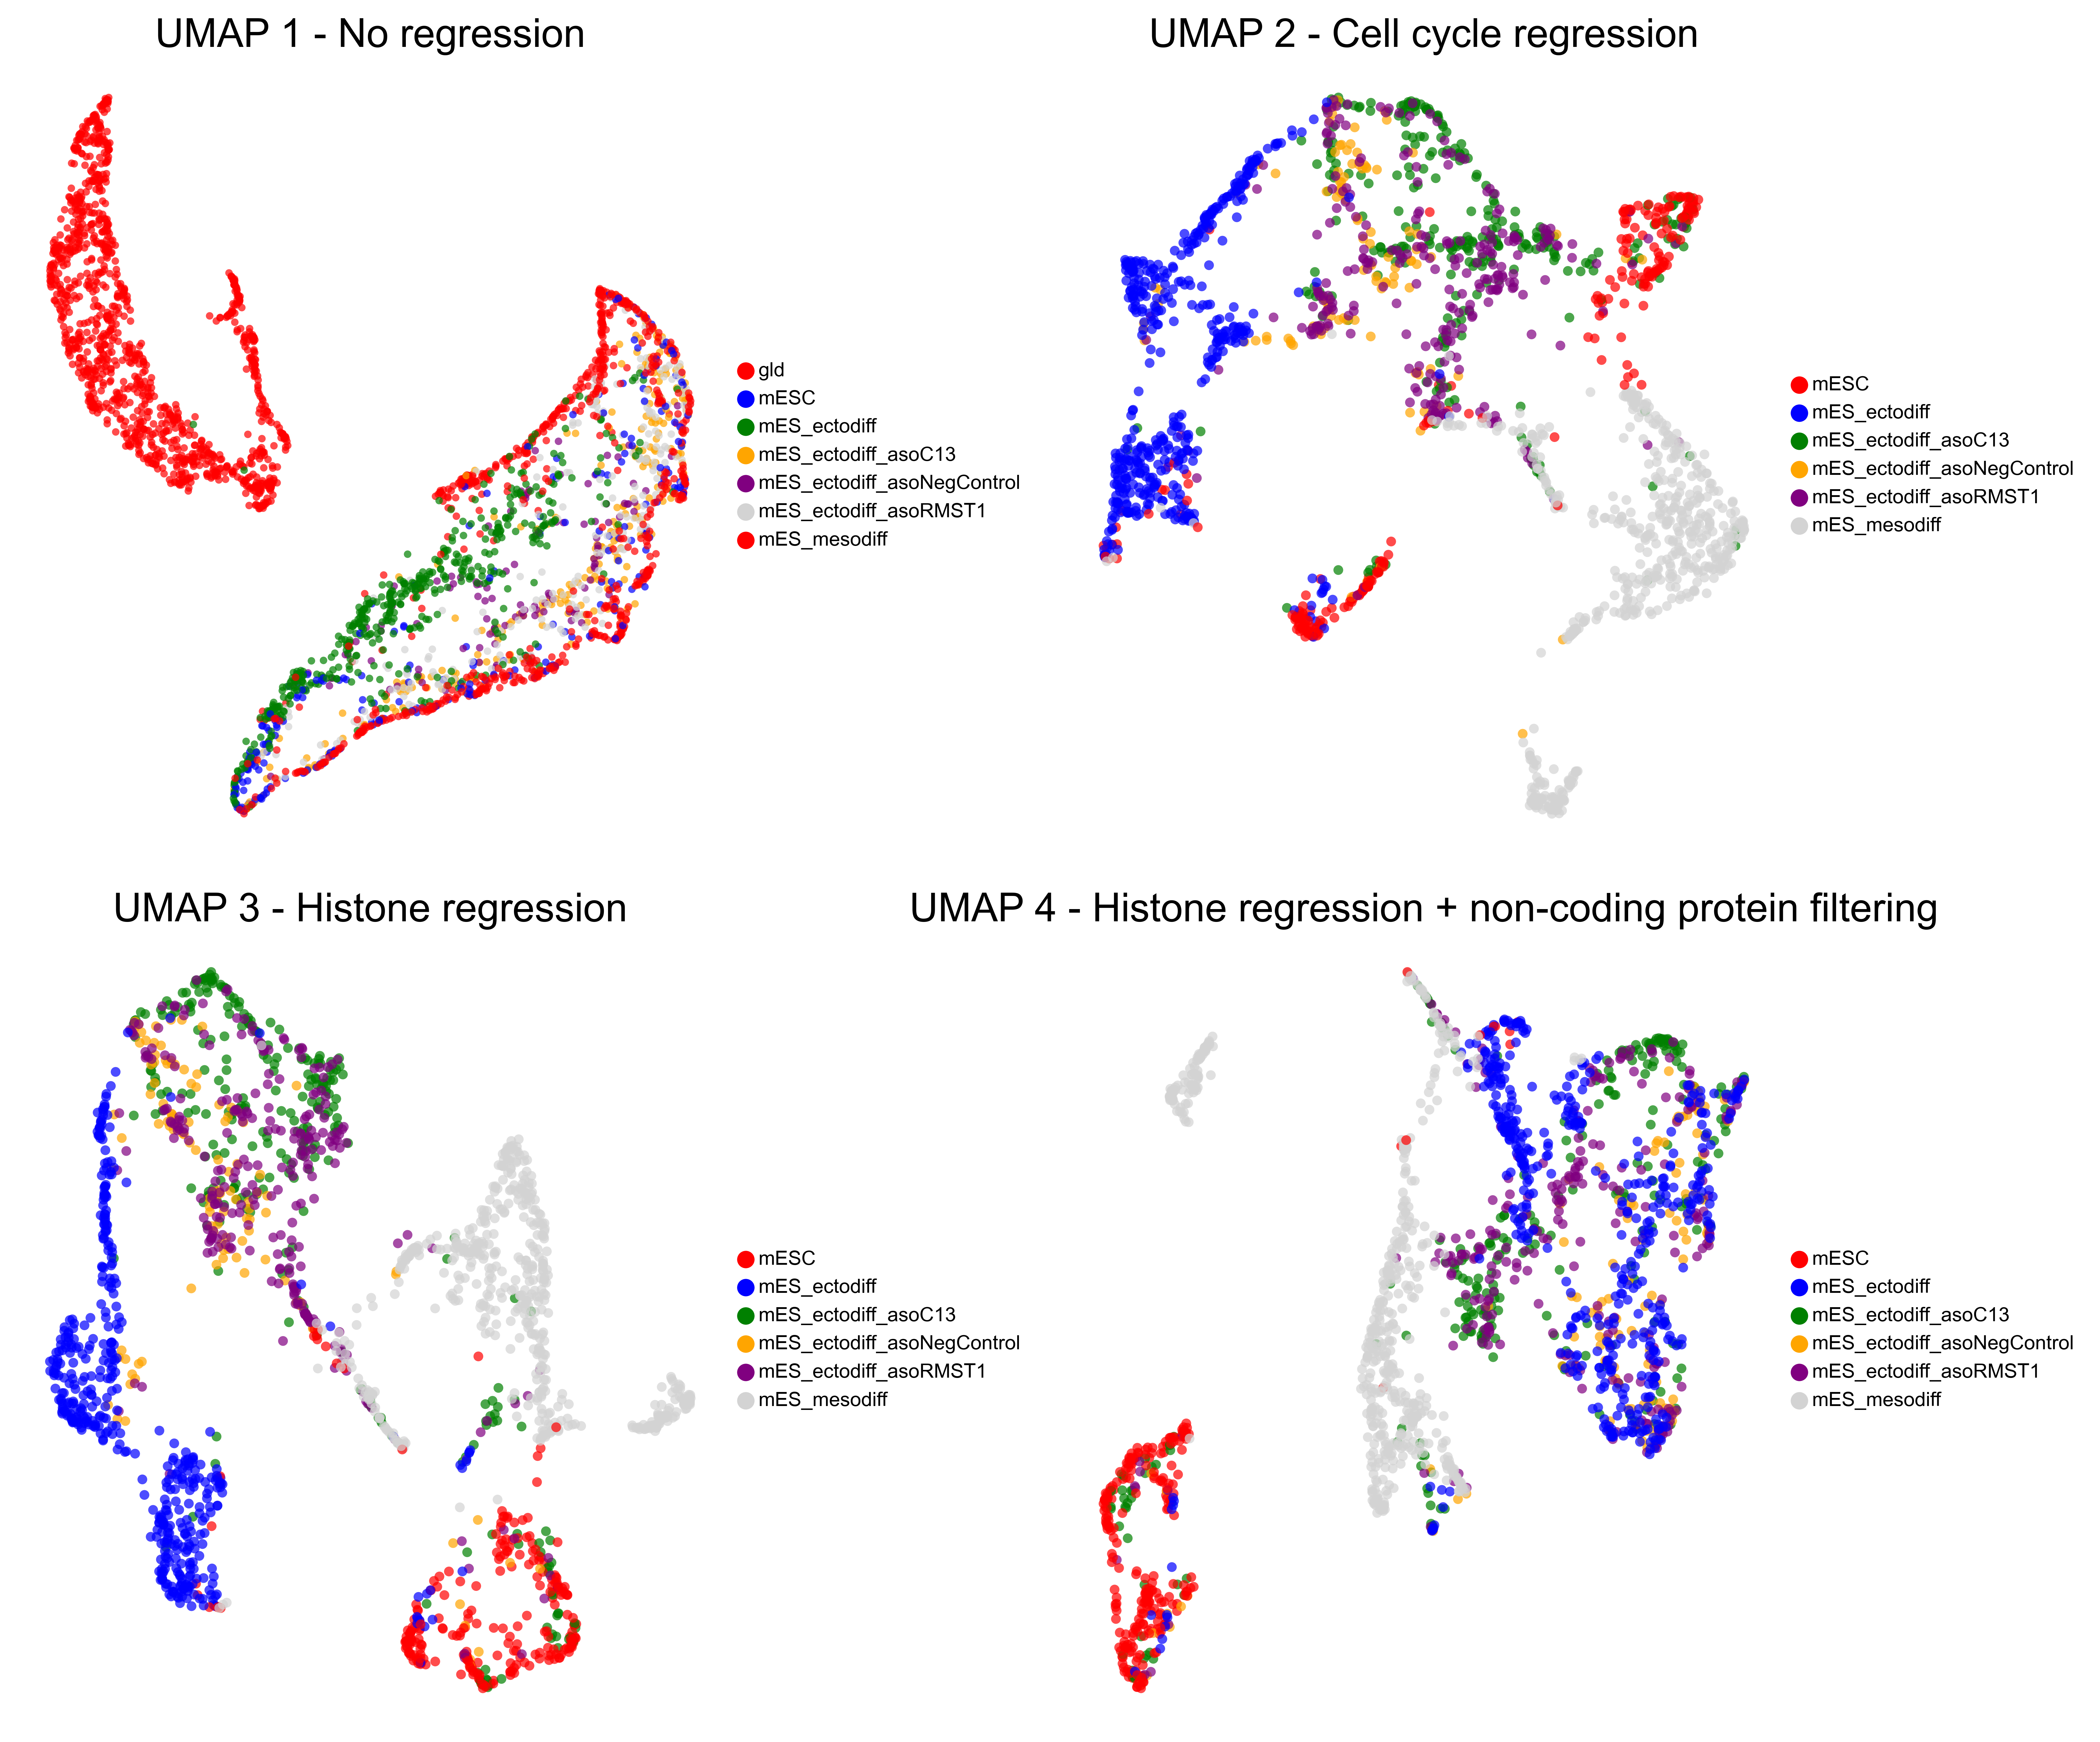

In [4]:
n_pcs_list = [optimal_pc_analytical1, optimal_pc_analytical2, optimal_pc_analytical3, optimal_pc_analytical4]
adata_list = [adata1, adata2, adata3, adata4]
titles = ['No regression', 'Cell cycle regression', 'Histone regression', 'Histone regression + non-coding protein filtering']  

# Subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (adata, n_pcs, title) in enumerate(zip(adata_list, n_pcs_list, titles)):
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs, copy=False)
    sc.tl.umap(adata, random_state=12, min_dist=0.1, spread=0.75)
    
    sc.pl.umap(
        adata,
        color=['diff_protocol'],
        palette=['red', 'blue', 'green', 'orange', 'purple', 'lightgrey'],
        alpha=0.7,
        legend_fontsize=8,
        title=f'UMAP {i+1} - {title}',
        ax=axes[i],
        show=False
    )

plt.tight_layout()
plt.show()